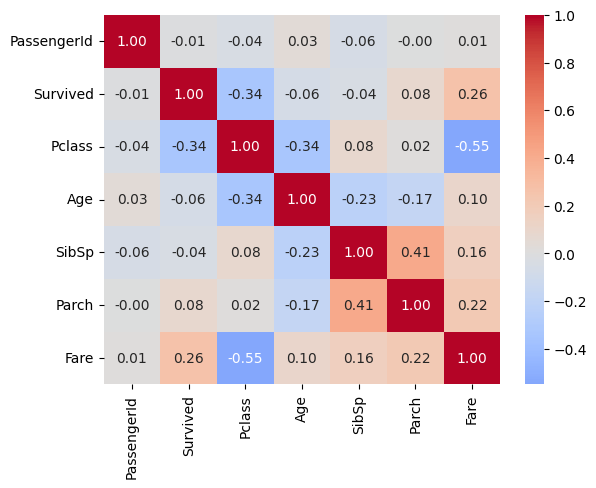

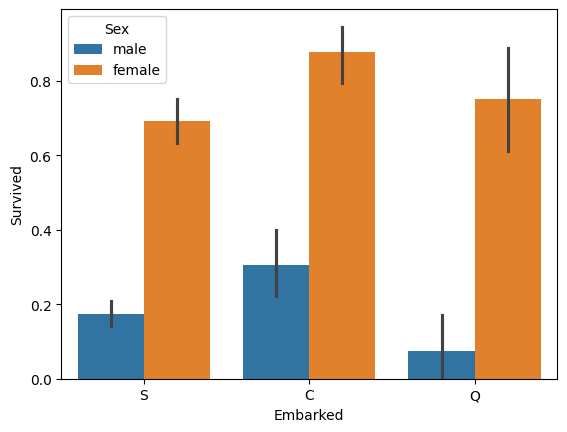

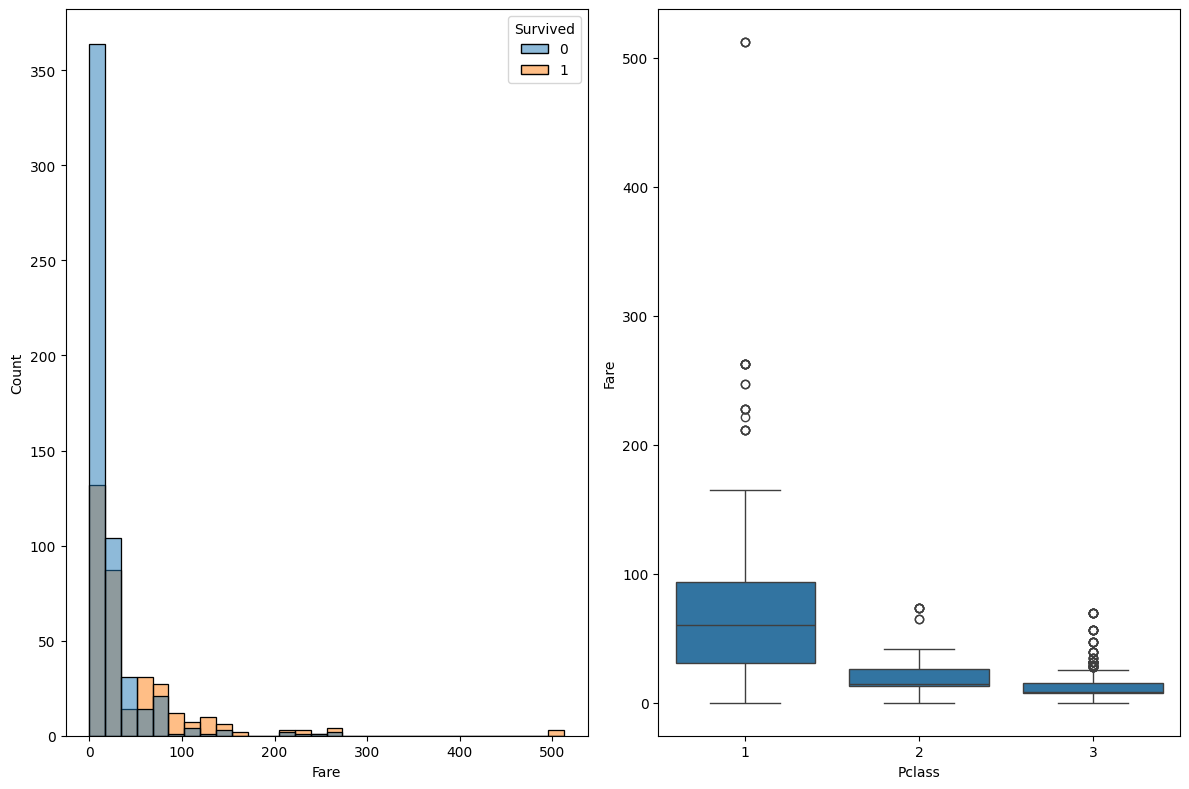

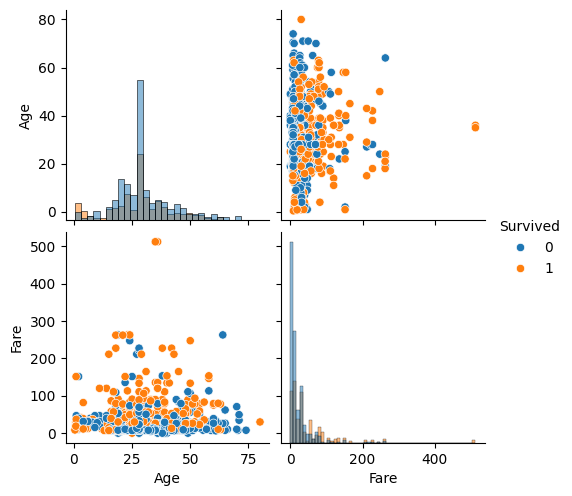

<Axes: xlabel='Age', ylabel='Fare'>

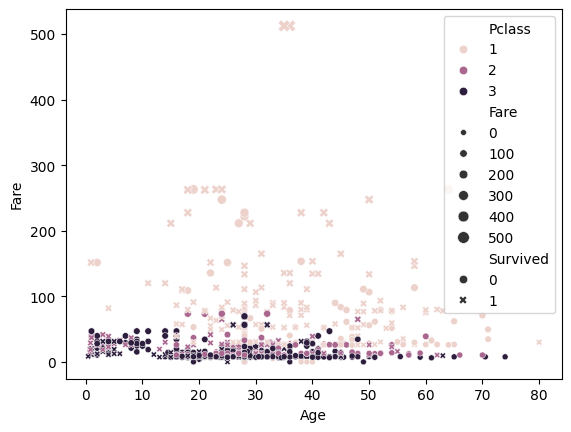

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop('Cabin', axis=1)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 1. Plot correlation heatmap
#    annot=True, fmt='.2f', cmap='coolwarm'
#    Which feature correlates most with Survived?
#ans:Pclass ,Fare
Corr=df.corr(numeric_only=True)
sns.heatmap(Corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.show()

# 2. Barplot — survival rate by Embarked port
#    hue='Sex'
#    Which port had highest female survival?
#ans:C port
sns.barplot(data=df,x='Embarked',y='Survived',hue='Sex')
plt.show()
# 3. Side by side subplots:
#    Left  — histplot of Fare, hue='Survived'
#    Right — boxplot of Fare by Pclass
#    tight_layout, titles on both
figs,axes=plt.subplots(1,2,figsize=(12,8))
sns.histplot(data=df,x='Fare',hue='Survived',bins=30,ax=axes[0])
sns.boxplot(data=df,x='Pclass',y='Fare',ax=axes[1])
plt.tight_layout()
plt.show()
# 4. Pairplot on ['Age','Fare','Survived']
#    hue='Survived', diag_kind='hist'
#    What pattern do you see?
#people with middle age has high fare and thier survival is more
cols=['Age','Fare','Survived']
sns.pairplot(df[cols],hue='Survived',diag_kind='hist')
plt.show()
# 5. Scatterplot — Age vs Fare
#    hue='Pclass', style='Survived'
#    size='Fare' — bigger dot = higher fare
#    What does this tell you?
#person with high fare in class1 so they survived more
sns.scatterplot(data=df,x='Age',y='Fare',hue='Pclass',style='Survived',size='Fare')